# Phase 7 — Degradation Modeling

## Four related, but different, PHM questions

- **Degradation modeling:** How does a condition/health measurement evolve as damage accumulates? A model might describe a latent health state or the trajectory of a candidate indicator.
- **Diagnosis:** What fault or failure mode is present now? Diagnosis assigns a current condition or cause from evidence; it is not a future-life estimate.
- **Prognosis:** What future condition or event is expected, and with what uncertainty? Prognosis needs a defensible time/damage coordinate, a validated model, and evidence that connects its state to future outcomes.
- **RUL prediction:** How much useful time (or cycles/dose) remain until a defined EoL? It is a particular prognosis and cannot be trained or evaluated responsibly until BoL, EoL, failure criteria, and censoring are defined.

A trend fit to a feature is therefore not automatically degradation modeling in the physical sense, diagnosis, prognosis, or RUL. In this lesson we fit a **descriptive linear baseline** to one candidate feature per device. The x-axis is within-device recorded clock time, only a proxy. We do not create an EoL time or RUL labels.

## 1. What model families might be appropriate?

Start with a plot and the simplest plausible baseline. More flexible models need stronger physical assumptions and more data:

| Model | Idea / when it may help | Important limitation here |
|---|---|---|
| **Linear regression** | A straight-line feature trend versus aging coordinate; transparent direction and rate, useful baseline. | Assumes a constant rate over the fitted interval. Operating-condition shifts can dominate; extrapolation is rarely safe. |
| **Polynomial regression** | Curvature in a trend when a curved shape is repeatable and supported by enough observations. | High-degree curves can fit noise and extrapolate wildly. A curved fit is not mechanistic evidence. |
| **Exponential model** | Accelerating change when a physical mechanism supports a specific exponential law and parameters/units are meaningful. | Do not choose it just because a curve looks steep. Requires positive/appropriate data and validation against alternatives. |
| **Wiener process** | Latent degradation with drift plus continuous random increments; can represent noisy paths that move both ways. | Diffusion/drift assumptions and a meaningful progression axis are needed; observed feature noise is not automatically process noise. |
| **Gamma process** | Monotone nonnegative increments for cumulative damage that should not reverse. | Unsuitable if the measured indicator legitimately moves both ways or is dominated by operating condition/noise. |
| **Kalman filter** | Linear-Gaussian latent state evolving over time with noisy observations; estimates a smoothed health state. | State transition and observation equations must be defensible; ordinary Kalman assumptions may be too restrictive. |
| **Particle filter** | Sequential state estimation for nonlinear/non-Gaussian dynamics using weighted particles. | Flexible but data- and compute-hungry; results depend on model choices and particle degeneracy. |
| **Gaussian Process (GP)** | Flexible function with uncertainty over a trend; kernels encode smoothness/scale assumptions. | Few independent devices limit learning; uncertainty grows in extrapolation, and a GP does not supply EoL physics. |

These methods answer different modeling needs. We are not implementing them all: the present data do not yet justify a stochastic damage law or a calibrated latent-state model.

## 2. Choose a transparent baseline and define its scope

We use **collector-emitter voltage peak-to-peak** as a mechanism-motivated candidate because switching-voltage behavior is electrically relevant and voltage peaks have been proposed as a candidate indicator in related experiment notes. This feature is only the minimum-to-maximum range of the **whole transient capture**: it is not an event-aligned overshoot, not calibrated here, and was not a consistent monotone trend across devices in Phase 6.

For each device independently, fit ordinary least squares:

$$\widehat{y}(t) = \beta_0 + \beta_1 t$$

where $y$ is the candidate feature and $t$ is elapsed recorded clock hours from that device's first non-`check` capture. Keep `check` records out of this trend fit because their filename marks a separate low-temperature test; do not interpret that exclusion as a health state. Use the earliest 70% of captures for fitting and the latest 30% as a chronological holdout, to illustrate how a straight line extrapolates even over a short horizon. This is a within-device descriptive exercise, **not** a transferable degradation model or RUL estimator.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

project_root = Path.cwd()
if not (project_root / "data" / "features").is_dir():
    project_root = project_root.parent

feature_path = project_root / "data" / "features" / "transient_candidate_features.csv"
if not feature_path.is_file():
    raise FileNotFoundError(
        f"{feature_path} was not found. Run notebooks/03_feature_engineering.ipynb first."
    )

observations = pd.read_csv(feature_path)
required = {
    "device_folder", "source_file", "timeEpoch", "collectorEmitterVoltage_peak_to_peak",
}
missing = sorted(required.difference(observations.columns))
if missing:
    raise ValueError(f"Feature table is missing required columns: {missing}")

observations["timeEpoch"] = pd.to_numeric(observations["timeEpoch"], errors="raise")
observations["collectorEmitterVoltage_peak_to_peak"] = pd.to_numeric(
    observations["collectorEmitterVoltage_peak_to_peak"], errors="raise"
)
observations["is_check_file"] = observations["source_file"].str.contains(
    "check", case=False, regex=False
)
aging = observations.loc[~observations["is_check_file"]].copy()
if aging.empty:
    raise ValueError("No non-check captures are available for this baseline.")

aging["elapsed_recorded_hours"] = np.nan
for device, indices in aging.groupby("device_folder", observed=True).groups.items():
    device_times = aging.loc[indices, "timeEpoch"]
    aging.loc[indices, "elapsed_recorded_hours"] = (device_times - device_times.min()) / 3600

feature_column = "collectorEmitterVoltage_peak_to_peak"
print(f"Candidate feature: {feature_column}")
print(f"Fit rows: {len(aging)}; devices: {aging['device_folder'].nunique()}")
print("Remember: recorded elapsed time is a proxy, not verified aging dose or cycles.")

Candidate feature: collectorEmitterVoltage_peak_to_peak
Fit rows: 688; devices: 4
Remember: recorded elapsed time is a proxy, not verified aging dose or cycles.


## 3. Fit one line per device and hold out later captures

We sort by recorded time before splitting to avoid randomly mixing future captures into training. The **training $R^2$** describes fit to the early portion; **holdout MAE** describes typical absolute error in the feature's own stored units on later captures. Neither metric says whether damage caused the feature change. Because there are few independent devices and stress settings change during the run, do not pool rows and report one deceptively precise score.

In [3]:
baseline_rows = []
prediction_frames = []
models = {}
for device, group in aging.groupby("device_folder", observed=True, sort=True):
    group = group.sort_values(["timeEpoch", "source_file"]).reset_index(drop=True)
    group = group.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["elapsed_recorded_hours", feature_column]
    )
    if len(group) < 5:
        raise ValueError(f"Need at least five captures for a temporal split; {device} has {len(group)}")

    split_at = int(np.floor(0.70 * len(group)))
    split_at = min(max(split_at, 2), len(group) - 2)
    train = group.iloc[:split_at]
    test = group.iloc[split_at:]
    model = LinearRegression()
    model.fit(train[["elapsed_recorded_hours"]], train[feature_column])
    train_prediction = model.predict(train[["elapsed_recorded_hours"]])
    test_prediction = model.predict(test[["elapsed_recorded_hours"]])
    models[device] = model

    baseline_rows.append({
        "device": device,
        "train_captures": len(train),
        "holdout_captures": len(test),
        "slope_feature_units_per_recorded_hour": float(model.coef_[0]),
        "intercept_feature_units": float(model.intercept_),
        "training_R2_descriptive": float(r2_score(train[feature_column], train_prediction)),
        "holdout_MAE_feature_units": float(mean_absolute_error(test[feature_column], test_prediction)),
    })

    predictions = group.copy()
    predictions["baseline_prediction"] = np.concatenate([train_prediction, test_prediction])
    predictions["baseline_split"] = ["train"] * len(train) + ["chronological holdout"] * len(test)
    prediction_frames.append(predictions)

baseline_metrics = pd.DataFrame(baseline_rows).set_index("device")
baseline_predictions = pd.concat(prediction_frames, ignore_index=True)
baseline_metrics.round(4)

,train_captures,holdout_captures,slope_feature_units_per_recorded_hour,intercept_feature_units,training_R2_descriptive,holdout_MAE_feature_units
device,,,,,,
Device 2,122,53,-0.4040,1.3449,0.3078,0.5815
Device 3,106,46,0.4416,1.2514,0.0511,0.3399
Device 4,178,77,1.4765,1.1105,0.5174,1.6535
Device 5,74,32,-0.4299,1.2969,0.4328,0.1720


## 4. Plot the fitted baseline and later-capture errors

Points are actual candidate-feature captures; solid lines are fitted values in the training interval and dashed lines are predictions in the later interval. The plot is intentionally split by device. Slopes in different devices may differ because the electrical stress schedule and acquisition conditions differ—not just because their degradation rates differ.

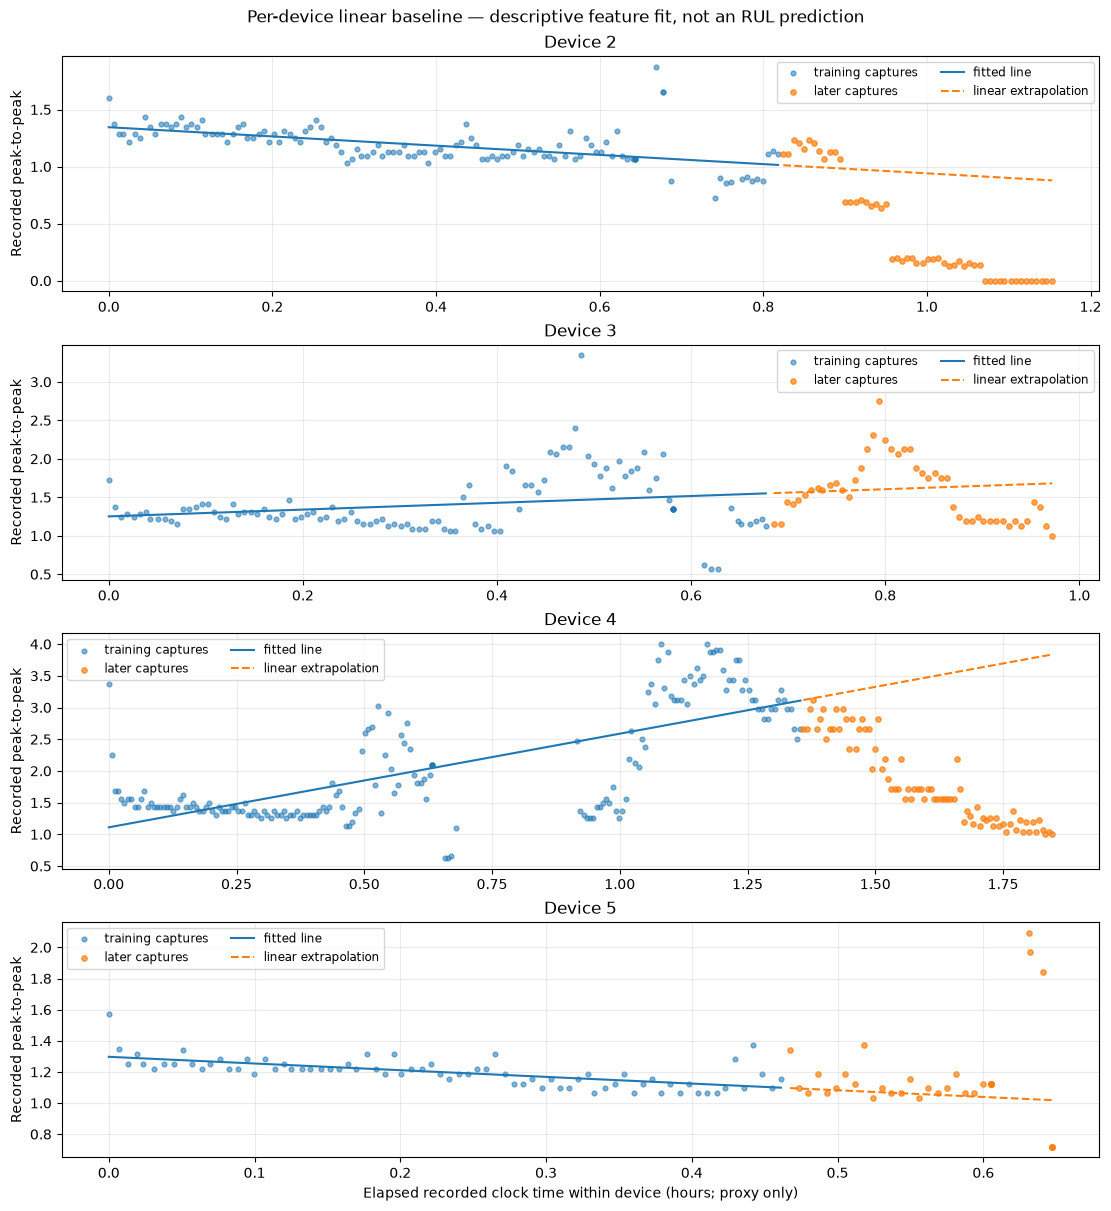

In [4]:
devices = sorted(aging["device_folder"].unique())
fig, axes = plt.subplots(
    len(devices), 1, figsize=(11, 3.0 * len(devices)), squeeze=False,
    constrained_layout=True,
)
for ax, device in zip(axes[:, 0], devices):
    group = baseline_predictions.loc[baseline_predictions["device_folder"] == device].sort_values("timeEpoch")
    train = group.loc[group["baseline_split"] == "train"]
    test = group.loc[group["baseline_split"] == "chronological holdout"]
    ax.scatter(train["elapsed_recorded_hours"], train[feature_column], s=12, alpha=0.55, label="training captures")
    ax.scatter(test["elapsed_recorded_hours"], test[feature_column], s=15, alpha=0.7, label="later captures")
    ax.plot(train["elapsed_recorded_hours"], train["baseline_prediction"], color="tab:blue", label="fitted line")
    ax.plot(test["elapsed_recorded_hours"], test["baseline_prediction"], "--", color="tab:orange", label="linear extrapolation")
    ax.set(title=device, ylabel="Recorded peak-to-peak")
    ax.grid(alpha=0.25)
    ax.legend(fontsize="small", ncol=2)
axes[-1, 0].set_xlabel("Elapsed recorded clock time within device (hours; proxy only)")
fig.suptitle("Per-device linear baseline — descriptive feature fit, not an RUL prediction")
plt.show()

## 5. Interpret the baseline honestly

Ask whether each line captures a stable progression or merely averages stage changes. Compare train and holdout visually, inspect whether the line extrapolates past observed feature behavior, and relate abrupt changes to file segments and stress settings in the aging log. A good holdout MAE would mean only that a straight line approximated later feature values for this short run; it would not prove sensitivity to damage or predict a failure.

The Phase 6 data showed mixed directions for this voltage peak-to-peak candidate across the four devices. That is a warning against forcing a common slope. This baseline also has no external operating variables, no verified aging coordinate, and no failure target. Treat it as a transparent reference to improve upon only after clarifying the experiment and EoL evidence.

## 6. Why not add curvature or stochastic models now?

**Polynomial regression** would add curvature parameters, but this small, staged experiment risks fitting operating-condition transitions and extrapolating unstable curves. **Exponential degradation** should be considered only if a proposed physical mechanism implies that law and calibrated observations support its assumptions; it is not a generic way to fit a rapid increase.

Wiener/Gamma processes and Kalman/particle filters represent latent degradation dynamics and measurement uncertainty; they require defensible state equations, noise models, and an aging coordinate. Gaussian Processes model flexible functions with uncertainty but cannot supply a physical EoL definition. All of these methods can appear sophisticated while faithfully modeling confounding or sensor drift. More complexity is not a remedy for missing labels or measurement uncertainty.

## Phase 7 learning check

1. What question does a degradation model answer that diagnosis does not?
2. Why does the linear model's slope describe feature change but not necessarily damage rate?
3. Why reserve the latest captures as a chronological holdout instead of randomly splitting the rows?
4. What evidence would justify trying a polynomial or exponential model?
5. Which assumptions distinguish Wiener and Gamma degradation processes?
6. How do Kalman, particle, and Gaussian-process approaches differ from a direct straight-line fit?
7. Why can none of the scores in this notebook be interpreted as RUL accuracy?

The next prerequisite for RUL is a defensible BoL/EoL/failure definition. The dataset records some event notes, but does not provide a standardized verified failure time for every device. Do not convert the last capture into a measured failure.